# EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Загрузка данных

Обеспечьте наличие [data/train.parquet](data/train.parquet) и [data/sample_submit.csv](data/sample_submit.csv) -- если по нажатию на их названия Вас не перекидывает, то
1. либо kernel не в корне,
2. либо Вы не скачали data после клонирования репозитория _(можно заморочиться и настроить github large files -- $\textcolor{red}{TODO}$)_.

In [2]:
df = pd.read_parquet('../data/train.parquet')
df['event_date'] = pd.to_datetime(df['event_date'])

In [3]:
df.shape

(30631006, 18)

In [4]:
df.columns.to_list()

['event_date',
 'user_id',
 'search',
 'cat',
 'has_search_to_cart',
 'has_search_to_ord',
 'has_cat_to_cart',
 'has_cat_to_ord',
 'search_to_cart',
 'search_to_ord',
 'cat_to_cart',
 'cat_to_ord',
 'gmv_search',
 'gmv_cat',
 'to_cart',
 'to_ord',
 'gmv',
 'searches']

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30631006 entries, 0 to 30631005
Data columns (total 18 columns):
 #   Column              Dtype        
---  ------              -----        
 0   event_date          datetime64[s]
 1   user_id             int64        
 2   search              int64        
 3   cat                 int64        
 4   has_search_to_cart  int64        
 5   has_search_to_ord   int64        
 6   has_cat_to_cart     int64        
 7   has_cat_to_ord      int64        
 8   search_to_cart      int64        
 9   search_to_ord       int64        
 10  cat_to_cart         int64        
 11  cat_to_ord          int64        
 12  gmv_search          float64      
 13  gmv_cat             float64      
 14  to_cart             int64        
 15  to_ord              int64        
 16  gmv                 float64      
 17  searches            int64        
dtypes: datetime64[s](1), float64(3), int64(14)
memory usage: 4.1 GB


Инты, флоты, но часть признаков -- категориальные, нужно будет энкодить

#### Прикладываю описания каждого из полей с [сайта](https://ods.ai/tracks/e-cup-2026-competitions/competitions/e-cup-2026-search/dataset):

`event_date` -- дата с 2025-01-01 по 2026-02-13  
`user_id` -- идентификатор пользователя  
`search` -- флаг пользования Поиском (0 или 1)  
`cat` -- флаг пользования Каталогом (0 или 1)  
`has_search_to_cart` -- флаг переноса товара в корзину при пользовании Поиском (0 или 1)  
`has_search_to_ord` -- флаг покупки товара при пользовании Поиском (0 или 1)  
`has_cat_to_cart` -- флаг переноса товара в корзину при пользовании Каталогом (0 или 1)  
`has_cat_to_ord` -- флаг покупки товара при пользовании Каталогом (0 или 1)  
`search_to_cart` -- число добавленных в корзину товаров при пользовании Поиском  
`search_to_ord` -- число купленных товаров при пользовании Поиском   
`cat_to_cart` -- число добавленных в корзину товаров при пользовании Каталогом  
`cat_to_ord` -- число купленных товаров при пользовании Каталогом   
`gmv_search` -- суммарная стоимость купленных товаров при пользовании Поиском  
`gmv_cat` -- суммарная стоимость купленных товаров при пользовании Каталогом  
`to_cart` -- суммарное число добавленных в корзину товаров  
`to_ord` -- суммарное число купленных товаров  
`gmv` -- суммарная стоимость купленных товаров  
`searches` -- суммарное число поисковых запросов  

In [6]:
df.head()

,event_date,user_id,search,cat,has_search_to_cart,has_search_to_ord,has_cat_to_cart,has_cat_to_ord,search_to_cart,search_to_ord,cat_to_cart,cat_to_ord,gmv_search,gmv_cat,to_cart,to_ord,gmv,searches
0,2025-06-16,2,1,0,0,0,0,0,0,0,0,0,0.0,0.0,0,0,0.0,2
1,2025-06-22,2,1,0,1,0,0,0,1,0,0,0,0.0,0.0,1,0,0.0,1
2,2025-08-08,2,1,0,0,0,0,0,0,0,0,0,0.0,0.0,0,0,0.0,1
3,2025-08-18,2,1,0,1,0,0,0,1,0,0,0,0.0,0.0,1,0,0.0,1
4,2025-08-23,2,1,0,0,0,0,0,0,0,0,0,0.0,0.0,0,0,0.0,1


## EDA

In [7]:
df.describe()

,event_date,user_id,search,cat,has_search_to_cart,has_search_to_ord,has_cat_to_cart,has_cat_to_ord,search_to_cart,search_to_ord,cat_to_cart,cat_to_ord,gmv_search,gmv_cat,to_cart,to_ord,gmv,searches
count,30631006,3.063101e+07,3.063101e+07,3.063101e+07,3.063101e+07,3.063101e+07,3.063101e+07,3.063101e+07,3.063101e+07,3.063101e+07,3.063101e+07,3.063101e+07,3.063101e+07,3.063101e+07,3.063101e+07,3.063101e+07,3.063101e+07,3.063101e+07
mean,2025-08-12 02:58:11,4.578321e+05,8.065806e-01,1.556473e-01,3.481047e-01,1.473676e-01,4.017364e-02,1.082250e-02,9.624454e-01,2.480173e-01,8.031803e-02,1.485256e-02,8.230486e+00,6.527215e-01,1.042763e+00,2.628699e-01,8.883207e+00,3.214340e+00
min,2025-01-01 00:00:00,2.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2025-05-04 00:00:00,2.265350e+05,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
50%,2025-08-24 00:00:00,4.569880e+05,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00
75%,2025-11-23 00:00:00,6.887500e+05,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,4.000000e+00
max,2026-02-13 00:00:00,9.184810e+05,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,8.160000e+02,1.380000e+02,1.535000e+03,6.800000e+01,7.383030e+04,1.883868e+04,1.535000e+03,1.380000e+02,7.383030e+04,6.300000e+02
std,NaN,2.657012e+05,3.949789e-01,3.625207e-01,4.763694e-01,3.544720e-01,1.963663e-01,1.034668e-01,2.403297e+00,8.550435e-01,7.328879e-01,1.925232e-01,6.300895e+01,1.871440e+01,2.574485e+00,8.903049e-01,6.613405e+01,5.101484e+00


В данных 250 тыс. пользователей; период наблюдений -- с 01.01.2025 по 13.02.2026.


**Наблюдение:** `search`, `cat` и `has_*` — бинарные признаки. У счетчиков переходов и GMV много нулей и длинный правый хвост, _можно будет накинуть логарифм_.


In [8]:
df.isnull().sum()

event_date            0
user_id               0
search                0
cat                   0
has_search_to_cart    0
has_search_to_ord     0
has_cat_to_cart       0
has_cat_to_ord        0
search_to_cart        0
search_to_ord         0
cat_to_cart           0
cat_to_ord            0
gmv_search            0
gmv_cat               0
to_cart               0
to_ord                0
gmv                   0
searches              0
dtype: int64

_Явных_ пропусков нет.


In [9]:
df.duplicated().sum()

np.int64(0)

Полных дубликатов -- тоже нет.


In [10]:
feature_cols = df.select_dtypes(include=np.number).columns
cat_cols = ['search', 'cat', 'has_search_to_cart', 'has_search_to_ord', 'has_cat_to_cart', 'has_cat_to_ord']
plot_df = df.sample(min(100_000, len(df)), random_state=42)


### Распределения признаков

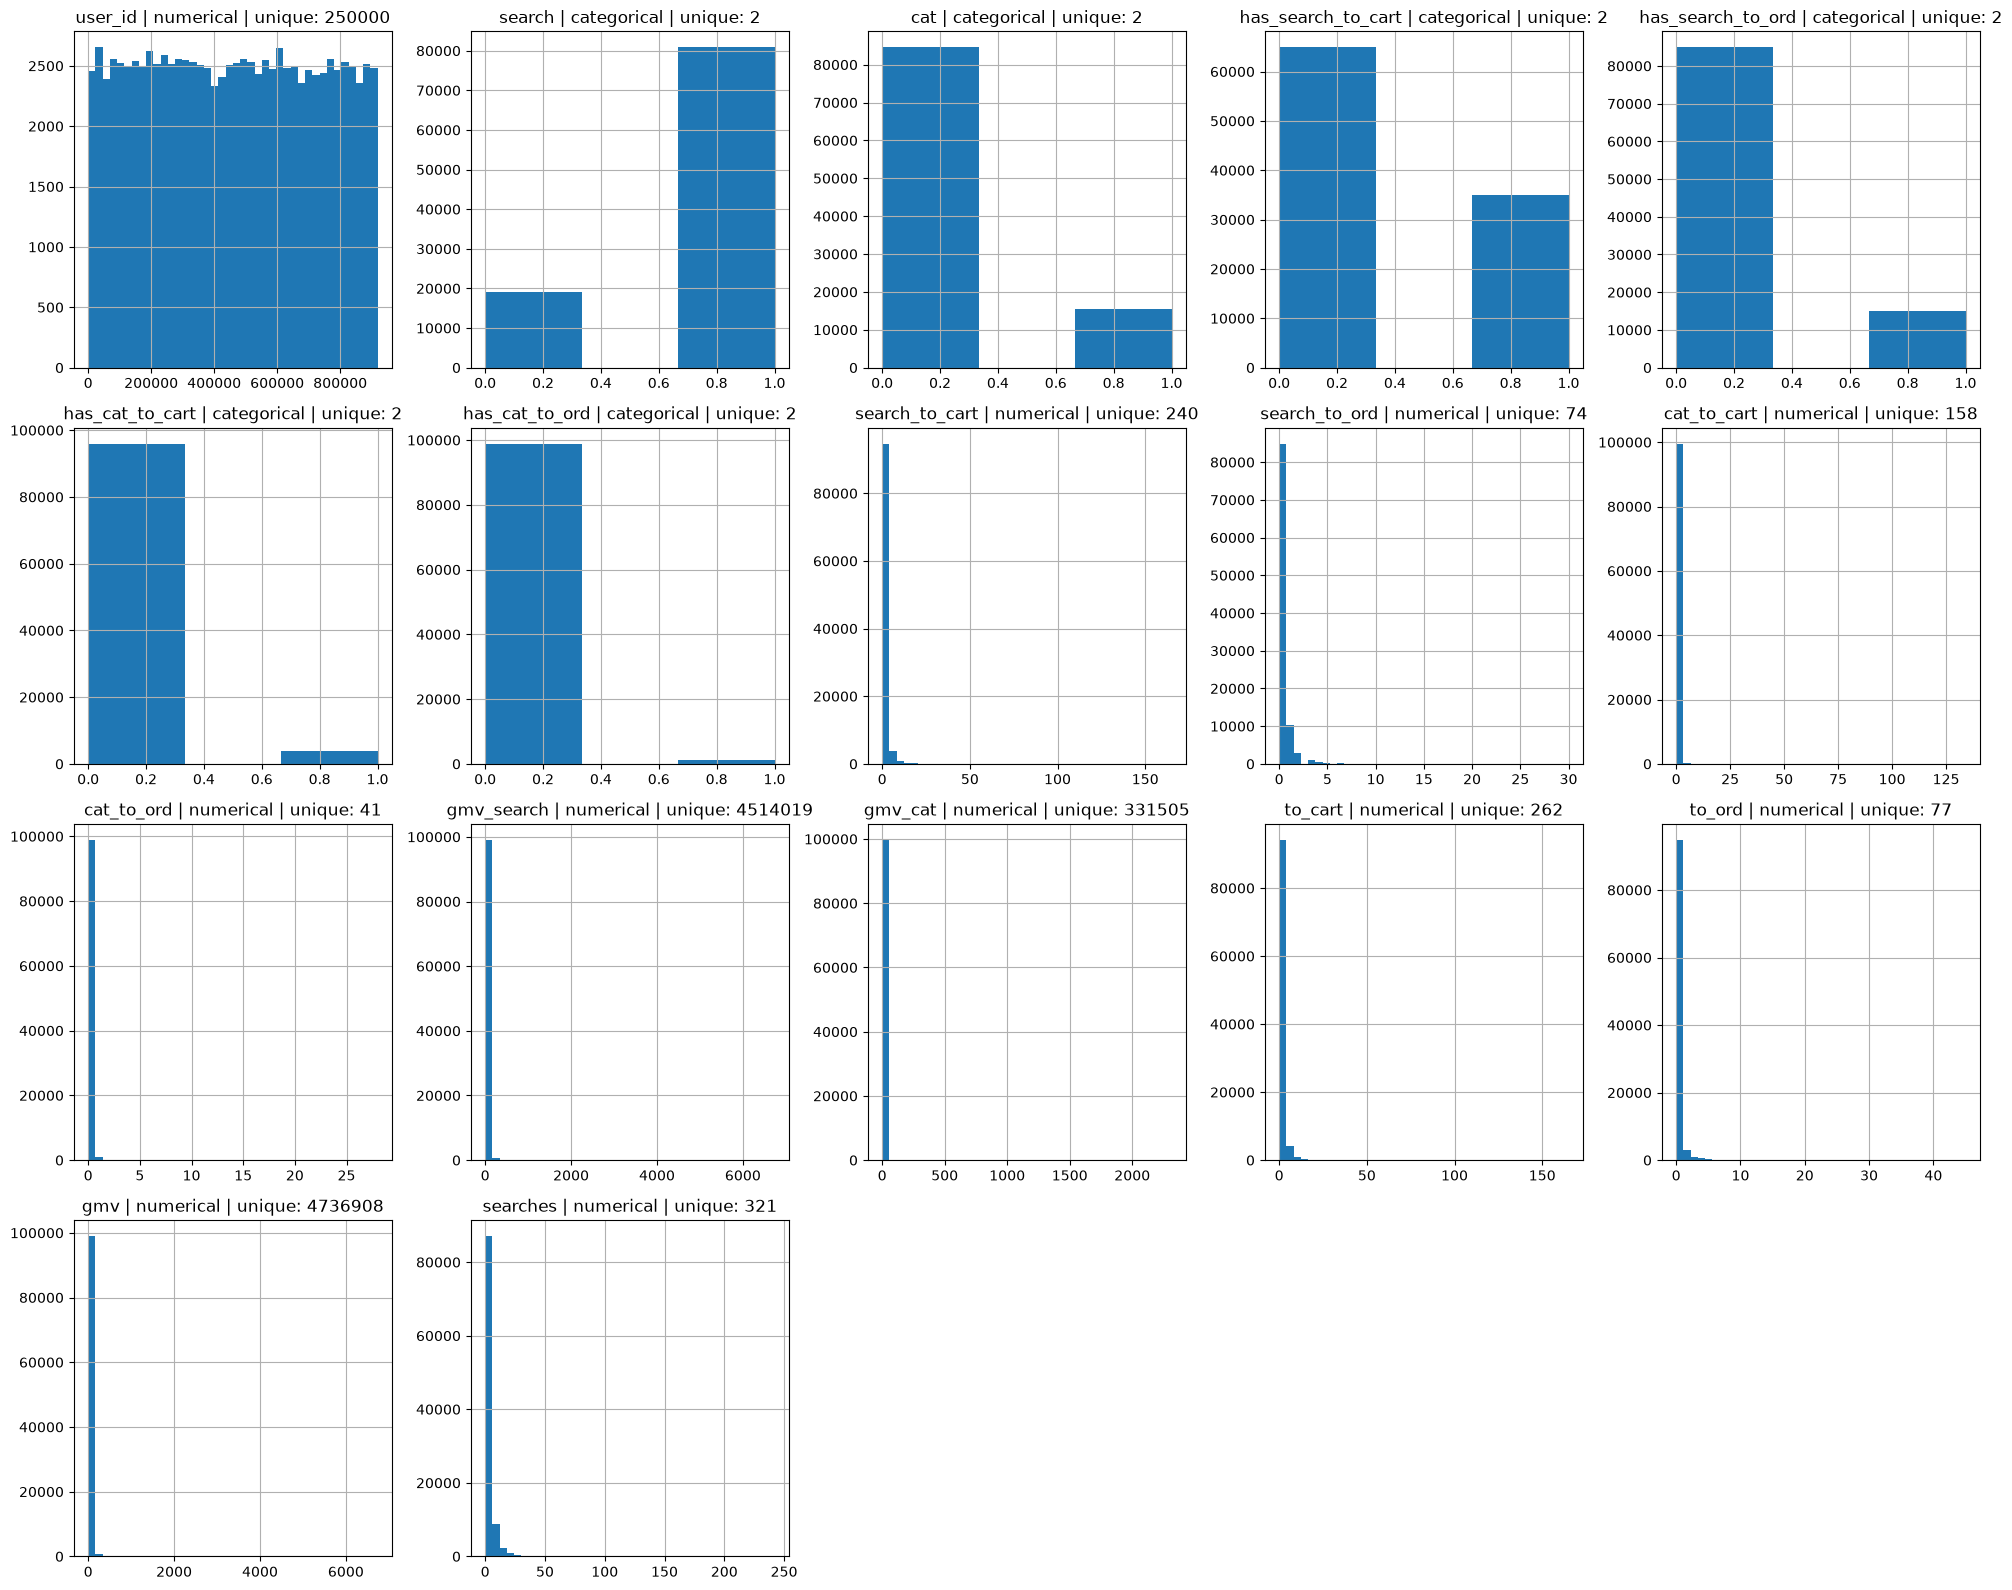

In [15]:
nrows, ncols = 4, 5
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20, 16))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    kind = 'categorical' if col in cat_cols else 'numerical'
    unique_count = df[col].nunique()

    plot_df[col].hist(bins=40 if kind=='numerical' else unique_count + (unique_count - 1), ax=axes[i])
    axes[i].set_title(f'{col} | {kind} | unique: {unique_count}')  # подписываю тип признака (категориальный / числовой) и число уникальных значений

for k in range(len(feature_cols), nrows * ncols):
    axes[k].set_visible(False)

plt.tight_layout()
plt.show()


Смотрите тип признака и число уникальных значений. У категориальных все ожидаемо, а вот у числовых -- **тяжелые хвосты, логарифм!**


### Активность по датам

In [ ]:
daily = df.groupby('event_date')['user_id'].agg(['size', 'nunique'])

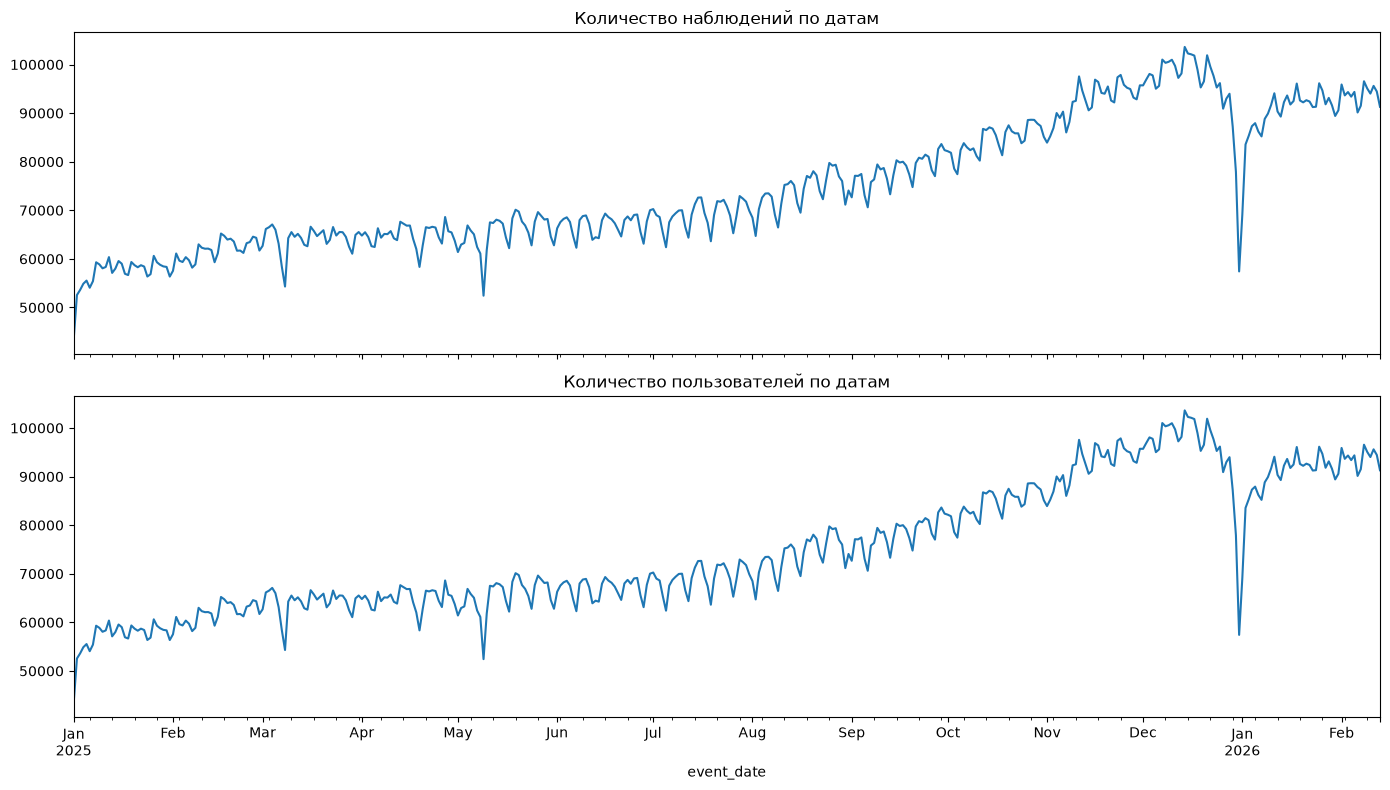

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

daily['size'].plot(ax=axes[0])
daily['nunique'].plot(ax=axes[1])
axes[0].set_title('Количество наблюдений по датам')
axes[1].set_title('Количество пользователей по датам')

plt.tight_layout()
plt.show()


Тренд -- восходящий; заметна недельная _(проверьте!)_ сезонность.


### Корреляции

In [ ]:
corr = df[feature_cols].corr()

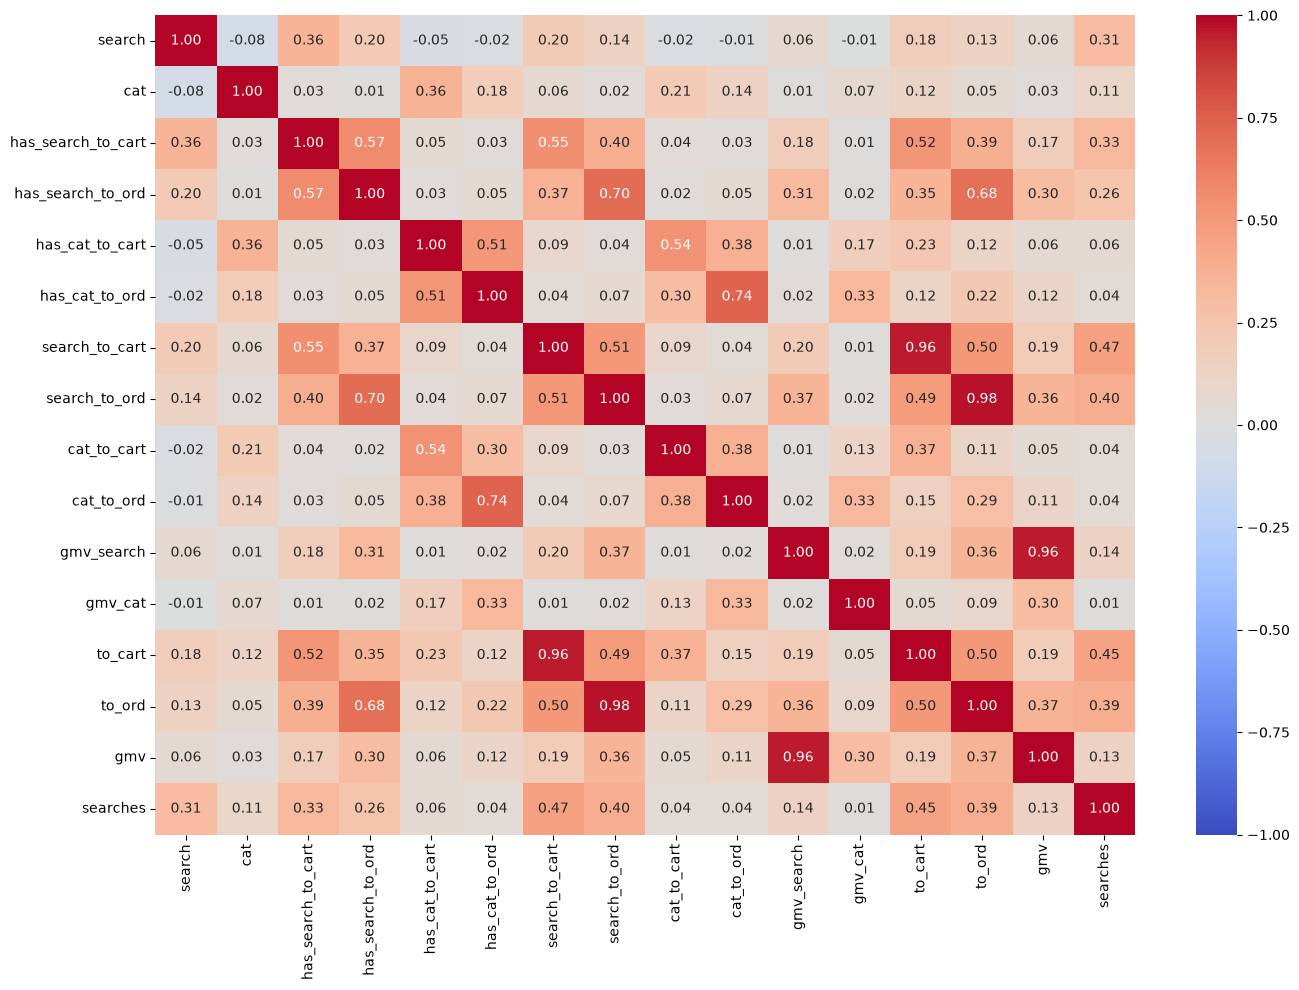

In [ ]:
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, ax=ax)

plt.tight_layout()
plt.show()


Наиболее сильные связи: `search_to_cart`–`to_cart`, `search_to_ord`–`to_ord`, `gmv_search`–`gmv`, что-нибудь наверняка можно будет дропнуть.


### Boxplot

In [ ]:
boxplot_cols = feature_cols


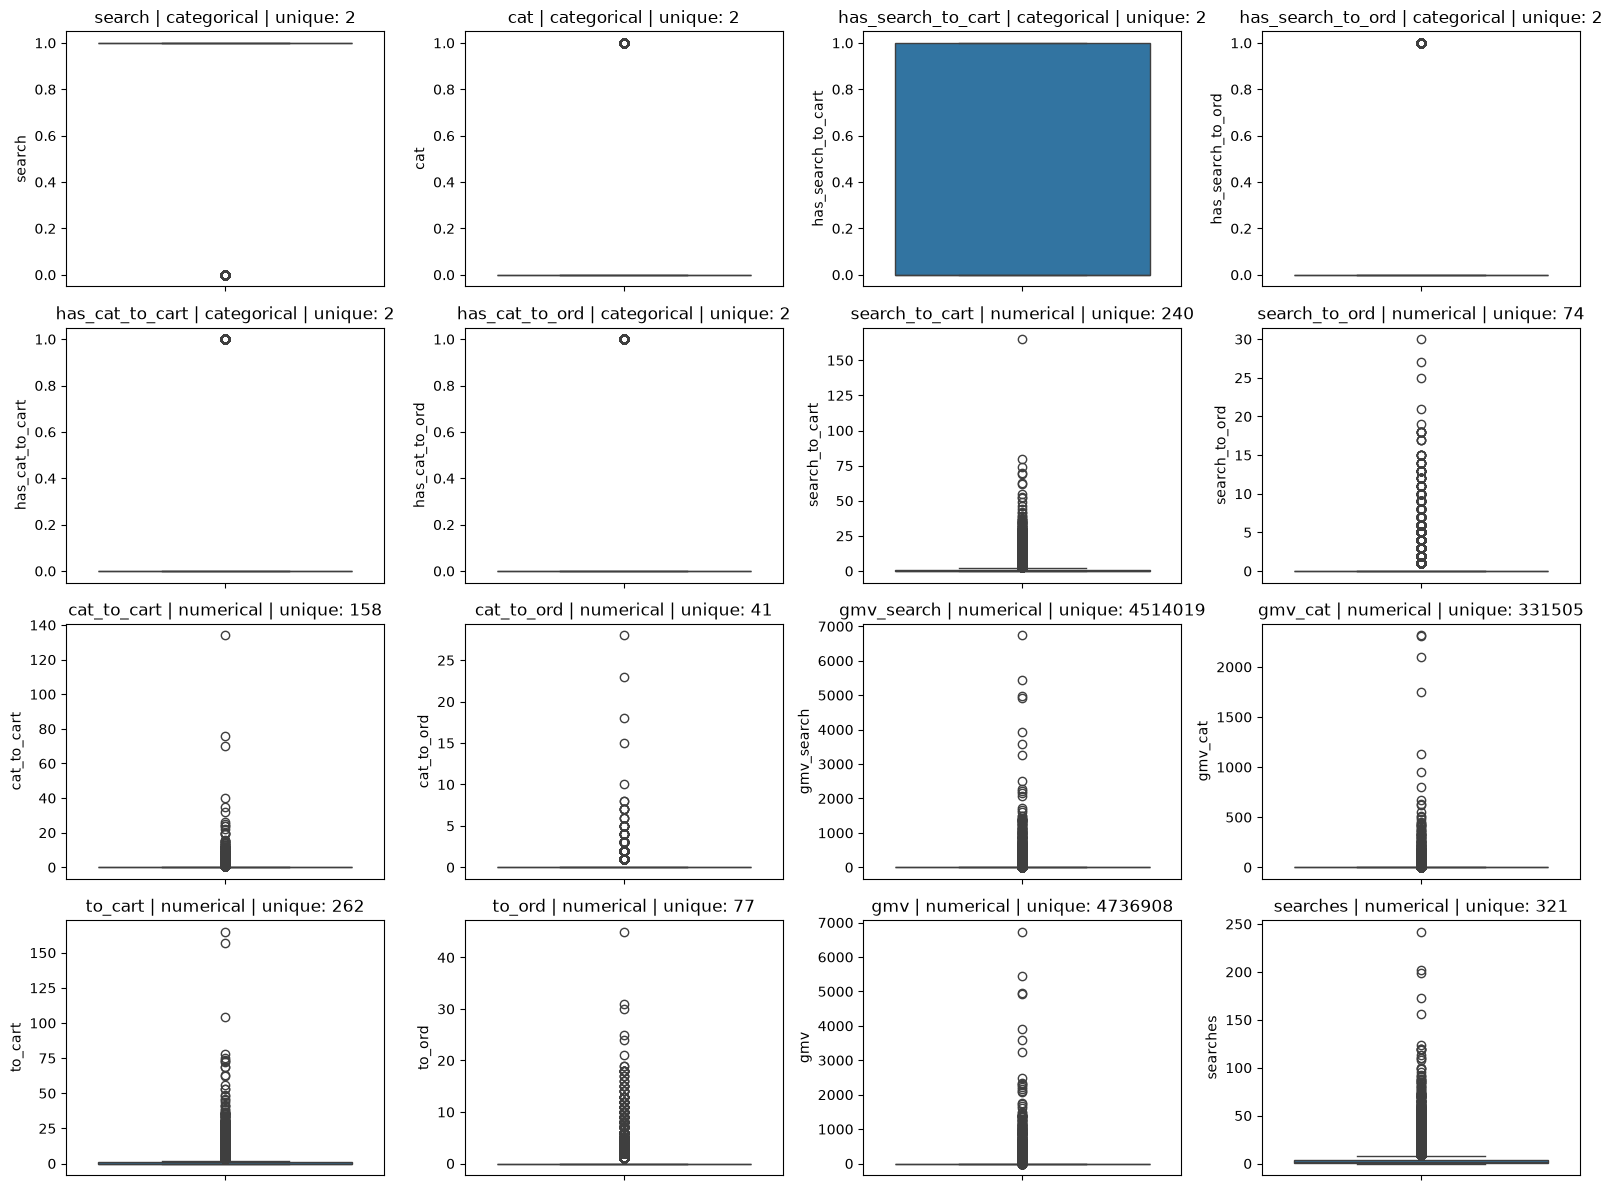

In [ ]:
fig, axes = plt.subplots(4, 4, figsize=(16, 12))

for ax, col in zip(axes.flat, boxplot_cols):
    sns.boxplot(y=plot_df[col], ax=ax)
    kind = 'categorical' if col in cat_cols else 'numerical'
    ax.set_title(f'{col} | {kind} | unique: {df[col].nunique()}')

plt.tight_layout()
plt.show()


Тут прям грустно, но большое число выбросов согласуется с длинными правыми хвостами на гистограммах.

### Pairplot

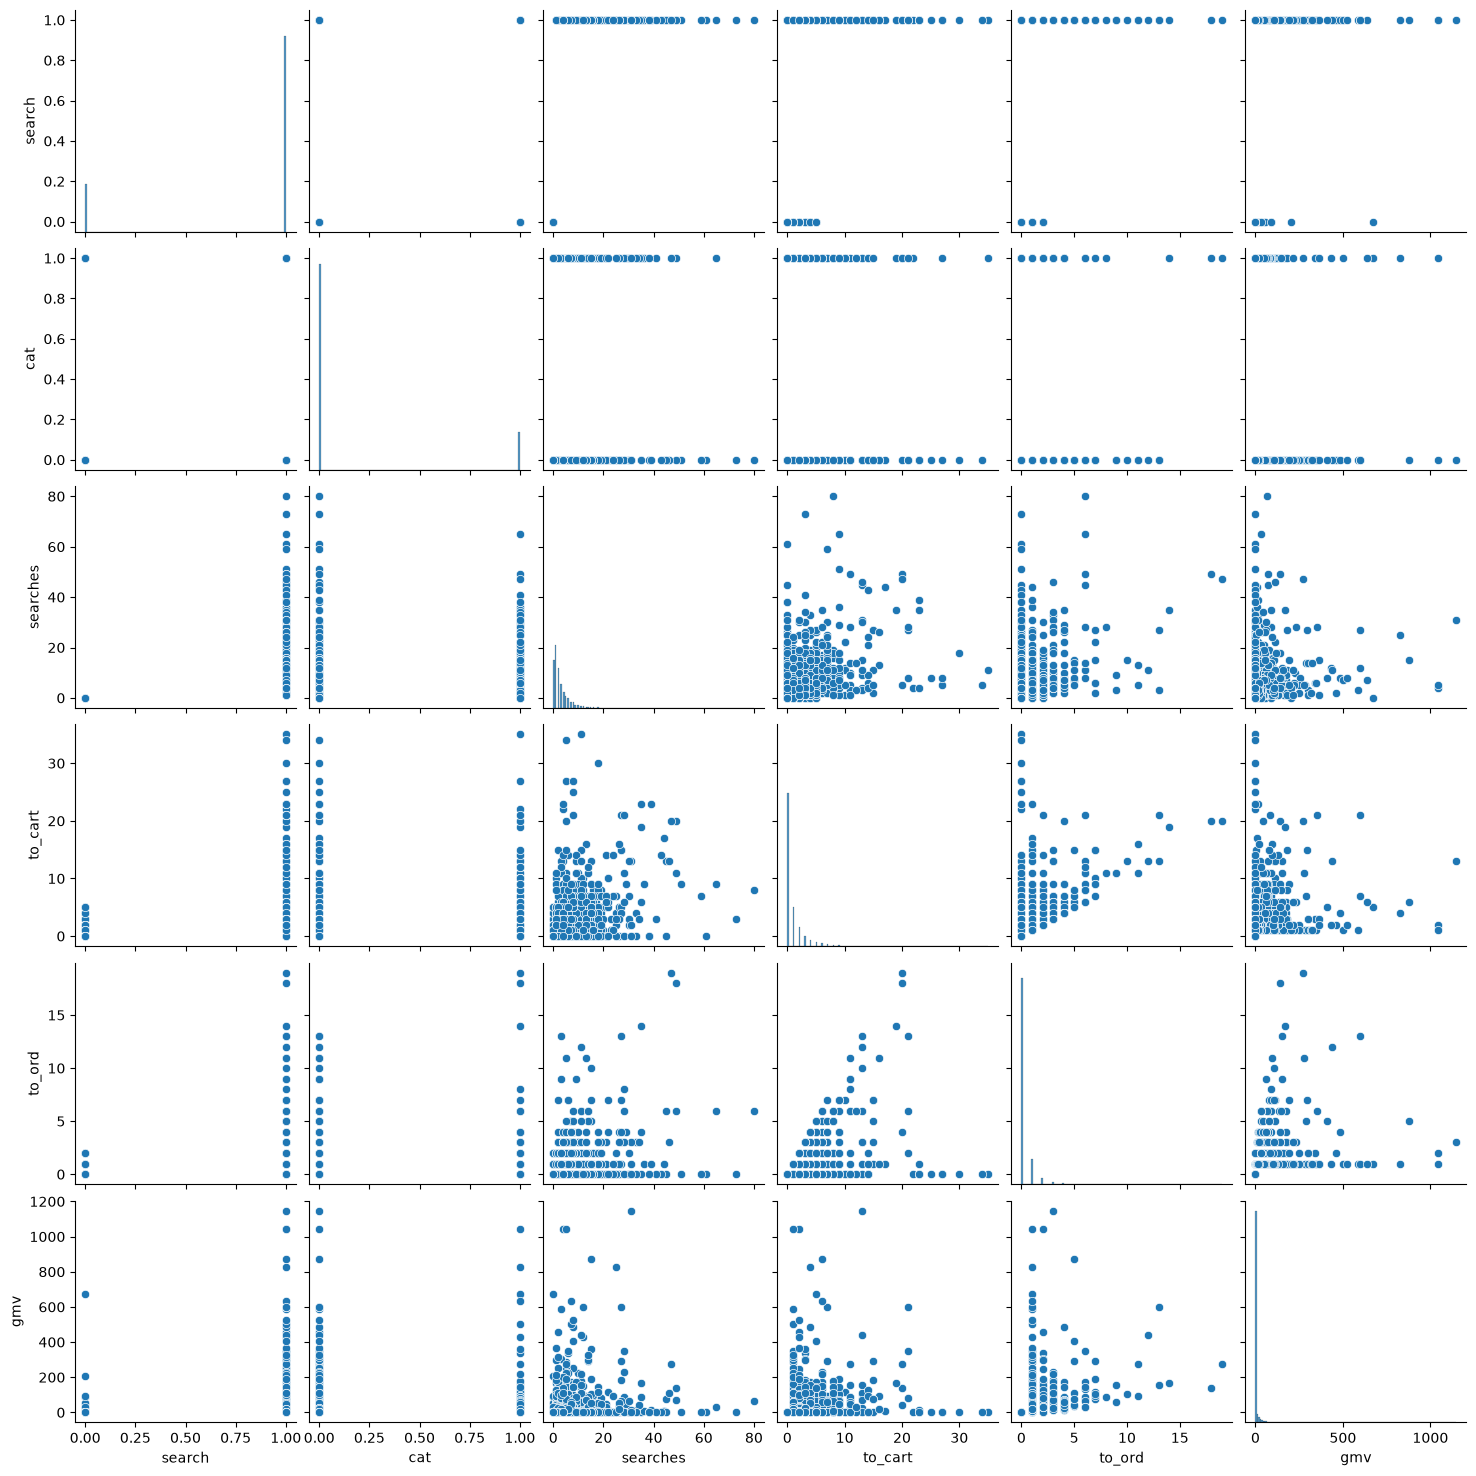

In [ ]:
g = sns.pairplot(plot_df[['search', 'cat', 'searches', 'to_cart', 'to_ord', 'gmv']].sample(min(5_000, len(plot_df)), random_state=42))
fig, axes = g.figure, g.axes
plt.show()


На pairplot основная масса точек сосредоточена около нуля из-за разреженности и сильной асимметрии признаков.


## PCA

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = StandardScaler().fit_transform(plot_df[feature_cols])
pca = PCA().fit(X)

In [ ]:
pca.explained_variance_ratio_

array([2.95184302e-01, 1.61918043e-01, 1.12899874e-01, 7.48922677e-02,
       6.79119209e-02, 5.72906202e-02, 5.25757506e-02, 4.71088707e-02,
       3.96203262e-02, 3.25882000e-02, 2.82496688e-02, 1.62341971e-02,
       1.35259578e-02, 9.22631432e-14, 2.08129883e-14, 0.00000000e+00])

### Explained variance

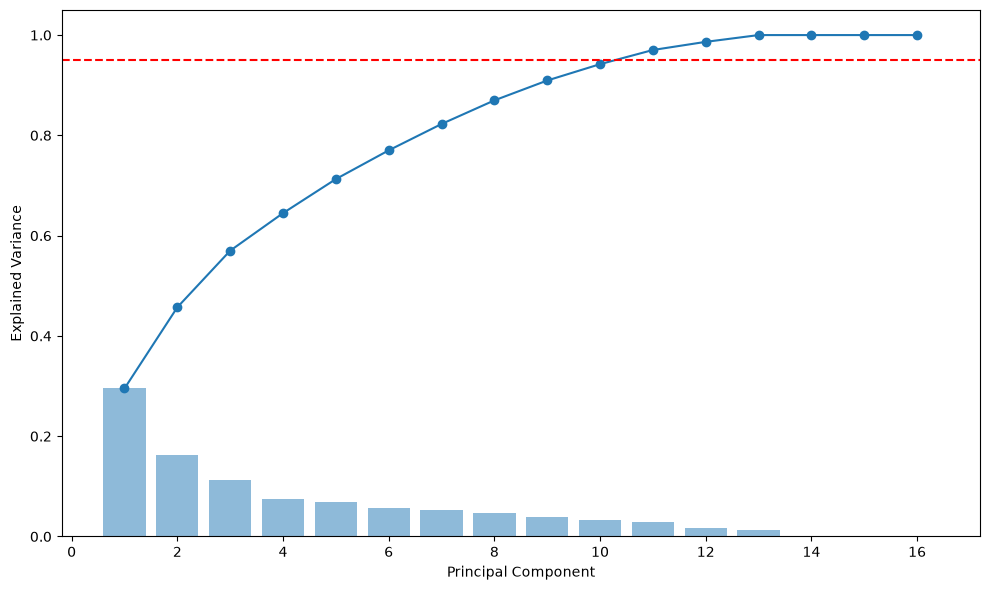

In [ ]:
x = np.arange(1, len(feature_cols) + 1)

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x, pca.explained_variance_ratio_, alpha=0.5)
ax.plot(x, np.cumsum(pca.explained_variance_ratio_), marker='o')
ax.axhline(0.95, color='red', linestyle='--')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance')

plt.tight_layout()
plt.show()


PC1 объясняет около 29.5% дисперсии, PC2 -- около 16.2%.

Около 95% дисперсии набирается примерно к 11-й компоненте; последние компоненты почти не добавляют дисперсии.



### Направления признаков

In [ ]:
loadings = pd.DataFrame(pca.components_[:2].T, index=feature_cols, columns=['PC1', 'PC2'])

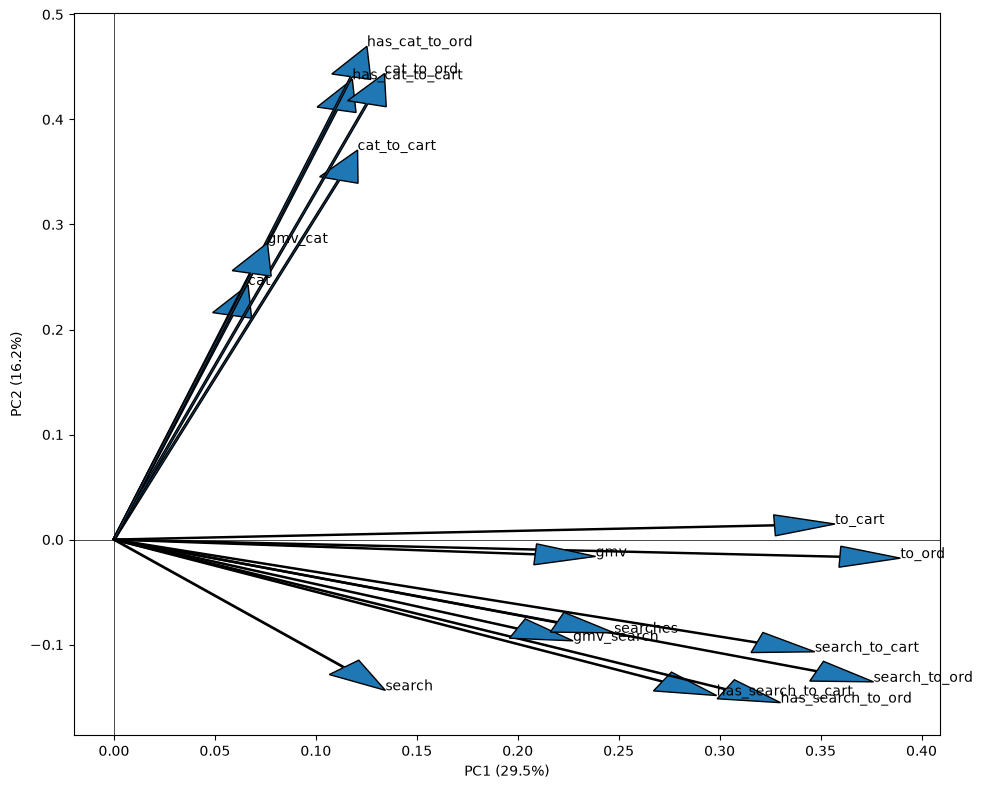

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))

for feature in feature_cols:
    x, y = loadings.loc[feature]
    ax.arrow(0, 0, x, y, head_width=0.02, length_includes_head=True)
    ax.text(x, y, feature)

ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.tight_layout()
plt.show()

Наибольшие нагрузки на первые компоненты имеют признаки, связанные с переходами в корзину/заказ и GMV; близкие направления соответствуют коррелирующим признакам, **можно кого-нибудь из них будет дропнуть!**


## Идеи для продолжения EDA

- Посмотреть сильно скошенные числовые признаки в `log1p`-масштабе.
- Проверить сезонность по дням недели и месяцам.
- Перейти от строк `user_id × day` к пользовательским агрегатам: суммы, средние, число активных дней, recency.
- Сравнить короткие и длинные окна активности пользователя.
- После построения локального target посмотреть его распределение и связи с признаками.

### Что здесь с целевой переменной

Отдельной колонки target в `train.parquet` нет. По условию нужно по истории активности пользователя предсказать **суммарную стоимость его заказов за следующие 30 дней**.

Для обучения target можно построить самим временным разбиением: выбрать дату cutoff, признаки считать только по истории до cutoff, а `y` -- как сумму `gmv` пользователя за следующие 30 дней. Для финального прогноза используем всю доступную историю и предсказываем уже неизвестные следующие 30 дней.


### **Посмотрите [01_EDA_no_outliers.ipynb](/notebooks/01_EDA_no_outliers.ipynb) -- убрал крайние значения по 1% и 99% квантилям из числовых признаков, более интересно получилось...**

Tbc...